In [1]:
from tensorflow import keras
import random

In [13]:
import os, shutil

In [14]:
random.seed(42)

source_base = r"D:\dataset"          
target_base = r"catVsdog"          

num_train = 1000
num_val = 500
num_test = 500
total_needed = num_train + num_val + num_test    

classes = {
    "Cat": "cats",
    "Dog": "dogs"
}

all_indices = list(range(12500))  

for class_name, folder_name in classes.items():
    src_dir = os.path.join(source_base, class_name)
    
    selected = random.sample(all_indices, total_needed)
    
    train_idx = selected[:num_train]
    val_idx = selected[num_train:num_train + num_val]
    test_idx = selected[num_train + num_val:]
    
    splits = {
        "train": train_idx,
        "validation": val_idx,
        "test": test_idx
    }
    
    for split, indices in splits.items():
        dest_dir = os.path.join(target_base, split, folder_name)
        os.makedirs(dest_dir, exist_ok=True)
        
        for i in indices:
            src_file = os.path.join(src_dir, f"{i}.jpg")
            dest_file = os.path.join(dest_dir, f"{i}.jpg")
            shutil.copy2(src_file, dest_file)  
    
    print(f"Successfully {class_name} ")

print("Well done!")

انتقال تصاویر کلاس Cat کامل شد.
انتقال تصاویر کلاس Dog کامل شد.
همه‌ی تصاویر با موفقیت کپی شدند.


In [16]:
base = "catVsdog"

def rename_and_distribute(class_folder_name, file_prefix):
    """
    Collects all images of a given class (e.g., 'cats' or 'dogs') from the 
    train, validation, and test folders, moves them to a temporary directory,
    renames them sequentially as 'file_prefix.0.jpg' ... 'file_prefix.1999.jpg',
    and finally redistributes them:
        - 0..999   -> train/{class_folder_name}
        - 1000..1499 -> validation/{class_folder_name}
        - 1500..1999 -> test/{class_folder_name}
    """
    # Gather all image paths from the three splits
    all_files = []
    for split in ["train", "validation", "test"]:
        folder = os.path.join(base, split, class_folder_name)
        for f in os.listdir(folder):
            if f.lower().endswith(".jpg"):
                all_files.append(os.path.join(folder, f))

    # Create a temporary folder and move everything there
    temp_dir = os.path.join(base, f"_temp_{class_folder_name}")
    os.makedirs(temp_dir, exist_ok=True)
    for f in all_files:
        shutil.move(f, temp_dir)

    # Sort files by their original number (assumed to be only the number, e.g., "123.jpg")
    temp_files = sorted(os.listdir(temp_dir), key=lambda x: int(os.path.splitext(x)[0]))
    # Rename them to the desired sequential format
    for i, old_name in enumerate(temp_files):
        new_name = f"{file_prefix}.{i}.jpg"
        os.rename(os.path.join(temp_dir, old_name), os.path.join(temp_dir, new_name))

    # Distribute the renamed files back into the proper folders
    # train: indices 0 to 999 (1000 images)
    dest_train = os.path.join(base, "train", class_folder_name)
    os.makedirs(dest_train, exist_ok=True)  # ensure the folder exists
    for i in range(1000):
        src = os.path.join(temp_dir, f"{file_prefix}.{i}.jpg")
        shutil.move(src, dest_train)

    # validation: indices 1000 to 1499 (500 images)
    dest_val = os.path.join(base, "validation", class_folder_name)
    os.makedirs(dest_val, exist_ok=True)
    for i in range(1000, 1500):
        src = os.path.join(temp_dir, f"{file_prefix}.{i}.jpg")
        shutil.move(src, dest_val)

    # test: indices 1500 to 1999 (500 images)
    dest_test = os.path.join(base, "test", class_folder_name)
    os.makedirs(dest_test, exist_ok=True)
    for i in range(1500, 2000):
        src = os.path.join(temp_dir, f"{file_prefix}.{i}.jpg")
        shutil.move(src, dest_test)

    # Remove the now-empty temporary folder
    os.rmdir(temp_dir)

# Apply the renaming and redistribution to cats and dogs
rename_and_distribute("cats", "cat")
rename_and_distribute("dogs", "dog")

print("All images have been renamed and redistributed successfully..!")

All images have been renamed and redistributed successfully..!


In [2]:
from keras import layers, models

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

C:\Users\aydin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,211,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from keras import optimizers

model.compile(loss='binary_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

# Data pre-processing

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = 'catVsdog/train'
validation_dir = 'catVsdog/validation'


# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [30]:
train_generator.class_indices

{'cats': 0, 'dogs': 1}

In [6]:
data, label = next(train_generator)

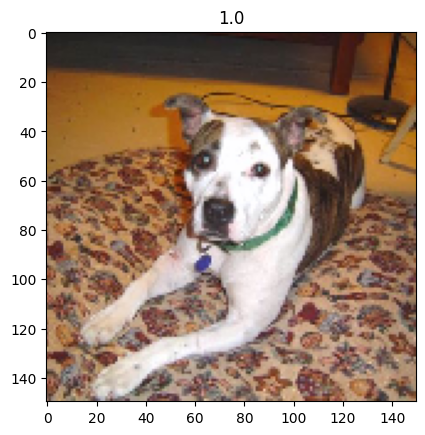

In [7]:
import matplotlib.pyplot as plt

plt.imshow(data[6])
plt.title(label[6]);

In [9]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 555ms/step - acc: 0.6075 - loss: 0.6524 - val_acc: 0.6300 - val_loss: 0.6491
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 59s 595ms/step - acc: 0.6695 - loss: 0.6236 - val_acc: 0.6350 - val_loss: 0.6344
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 64s 641ms/step - acc: 0.6780 - loss: 0.5943 - val_acc: 0.6800 - val_loss: 0.5981
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 68s 683ms/step - acc: 0.7100 - loss: 0.5651 - val_acc: 0.6400 - val_loss: 0.6240
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 701ms/step - acc: 0.7245 - loss: 0.5454 - val_acc: 0.6620 - val_loss: 0.5998
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 63s 631ms/step - acc: 0.7405 - loss: 0.5234 - val_acc: 0.6760 - val_loss: 0.6320
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 601ms/step - acc: 0.7535 - loss: 0.4950 - val_acc: 0.6970 - val_loss: 0.5917
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 64s 643ms/step - acc: 0.7735 - loss: 0.4760 - val_acc: 0.7200 - val_loss: 0.5597
Epoch 9/10
100/100 ━━━━━━━━━━━━━

In [10]:
model.save('cats_and_dogs_small_1.h5')